| Business Question                                | Why management cares      |
| ------------------------------------------------ | ------------------------- |
| How many customers do we have?                   | Customer base             |
| How many actually own policies?                  | Conversion/penetration    |
| How many policies per customer?                  | Cross-sell potential      |
| Which policy types sell most?                    | Product mix               |
| Which products generate the most annual premium? | Portfolio contribution    |
| Which policies are Active/Lapsed/Cancelled?      | Portfolio health          |
| Which channels sell policies?                    | Distribution performance  |
| Which states contribute business?                | Geographic performance    |
| What is the customer risk mix?                   | Portfolio risk            |
| Do higher-risk customers pay higher premiums?    | Pricing/risk relationship |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
    
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data" / "raw"

print(DATA_DIR)

f:\insurance_ai_copilot\data\raw


In [3]:
print(DATA_DIR.exists())

True


Load only required datasets

In [4]:
customers_df = pd.read_csv(
    DATA_DIR / "customers.csv"
)

policies_df = pd.read_csv(
    DATA_DIR / "policies.csv"
)

print("Customers :", customers_df.shape)
print("Policies  :", policies_df.shape)

Customers : (100000, 12)
Policies  : (150000, 15)


First understand the relationship

CUSTOMERS
    │
    │ CUSTOMER_ID
    │
    │ 1 : Many
    ↓
POLICIES

Customers grain = one row/customer

Policies grain = one row/policy

Merge Customers and Policies

Customers → CUSTOMER_ID unique
Policies  → CUSTOMER_ID repeated

In [5]:
customer_policy_df = policies_df.merge(
    customers_df,
    on="CUSTOMER_ID",
    how="left",
    validate="many_to_one"
)

In [6]:
customer_policy_df.shape

(150000, 26)

validate="many_to_one"

“I expect many policy rows to match exactly one customer.”

If customer IDs unexpectedly duplicate in customers_df, Pandas raises an error.

This helps us prevent bad joins.

“I validated merge cardinality(relationship) explicitly using many-to-one joins to prevent accidental row multiplication.”

Validate merge

In [7]:
customer_policy_df[
    "CUSTOMER_NAME"
].isna().sum()

np.int64(0)

Meaning every policy found its customer.

Our first KPI dashboard

In [8]:
total_customers = customers_df["CUSTOMER_ID"].nunique()

policy_customers = policies_df["CUSTOMER_ID"].nunique()

total_policies = policies_df["POLICY_ID"].nunique()

customers_without_policy = (
    total_customers - policy_customers
)

avg_policies_per_policyholder = (
    total_policies / policy_customers
)

total_annual_premium = policies_df[
    "ANNUAL_PREMIUM"
].sum()

avg_annual_premium = policies_df[
    "ANNUAL_PREMIUM"
].mean()

In [9]:
print("Total Customers:", total_customers)

print(
    "Customers with Policy:",
    policy_customers
)

print(
    "Customers without Policy:",
    customers_without_policy
)

print(
    "Total Policies:",
    total_policies
)

print(
    "Avg Policies per Policyholder:",
    round(avg_policies_per_policyholder, 2)
)

print(
    "Total Annual Premium:",
    total_annual_premium
)

print(
    "Avg Annual Premium:",
    round(avg_annual_premium, 2)
)

Total Customers: 100000
Customers with Policy: 77891
Customers without Policy: 22109
Total Policies: 150000
Avg Policies per Policyholder: 1.93
Total Annual Premium: 2879271171
Avg Annual Premium: 19195.14


“Total annual premium represented by the policy portfolio.”

First Business Insight — Policy Penetration

In [10]:
policyholder_pct = (
    policy_customers
    /
    total_customers
    * 100
)

non_policyholder_pct = (
    customers_without_policy
    /
    total_customers
    * 100
)

print(
    "Policyholders:",
    round(policyholder_pct, 2),
    "%"
)

print(
    "Customers without policy:",
    round(non_policyholder_pct, 2),
    "%"
)

Policyholders: 77.89 %
Customers without policy: 22.11 %


In [11]:
policies_per_customer = (
    policies_df
    .groupby("CUSTOMER_ID")
    ["POLICY_ID"]
    .count()
)

In [12]:
policies_per_customer.head()

CUSTOMER_ID
CUST00000002    1
CUST00000003    1
CUST00000004    3
CUST00000005    2
CUST00000006    1
Name: POLICY_ID, dtype: int64

Policy count distribution

In [13]:
policy_count_distribution = (
    policies_per_customer
    .value_counts()
    .sort_index()
)

policy_count_distribution

POLICY_ID
1    33761
2    24980
3    12718
4     4604
5     1366
6      371
7       76
8       14
9        1
Name: count, dtype: int64

In [14]:
single_policy_customers = (
    policies_per_customer == 1
).sum()

single_policy_pct = (
    single_policy_customers
    /
    policy_customers
    * 100
)

print(
    round(single_policy_pct, 2),
    "%"
)

43.34 %


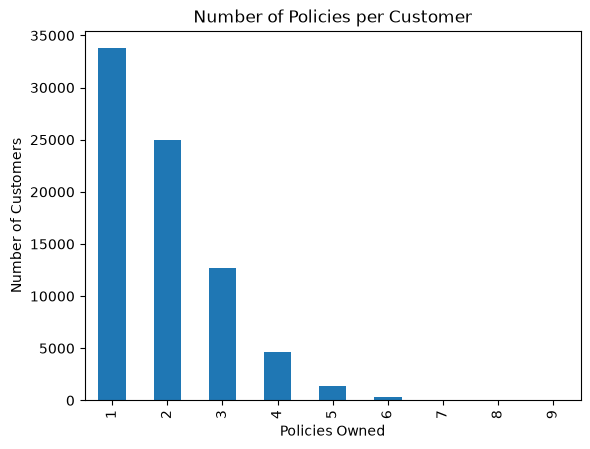

In [15]:
policy_count_distribution.plot(
    kind="bar"
)

plt.title(
    "Number of Policies per Customer"
)

plt.xlabel(
    "Policies Owned"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

In [16]:
# Which insurance products sell most?
policy_type_summary = (
    policies_df
    .groupby("POLICY_TYPE")
    .agg(
        POLICY_COUNT=("POLICY_ID", "count"),
        TOTAL_ANNUAL_PREMIUM=(
            "ANNUAL_PREMIUM",
            "sum"
        ),
        AVG_ANNUAL_PREMIUM=(
            "ANNUAL_PREMIUM",
            "mean"
        )
    )
    .reset_index()
)

In [17]:
policy_type_summary[
    "POLICY_SHARE_PCT"
] = (
    policy_type_summary["POLICY_COUNT"]
    /
    policy_type_summary["POLICY_COUNT"].sum()
    * 100
)

In [18]:
policy_type_summary = (
    policy_type_summary
    .sort_values(
        "POLICY_COUNT",
        ascending=False
    )
)

policy_type_summary

,POLICY_TYPE,POLICY_COUNT,TOTAL_ANNUAL_PREMIUM,AVG_ANNUAL_PREMIUM,POLICY_SHARE_PCT
1,Health,36123,691504863,19143.062952,24.082000
3,Motor,31768,473105342,14892.512654,21.178667
5,Term Life,23933,407853096,17041.453056,15.955333
0,Commercial,14892,710527898,47712.053317,9.928000
2,Home,12031,140543311,11681.764691,8.020667
4,Personal Accident,11989,70110049,5847.864626,7.992667
7,Whole Life,10302,352284979,34195.785187,6.868000
6,Travel,8962,33341633,3720.333966,5.974667


In [19]:
premium_product_summary = (
    policy_type_summary
    .sort_values(
        "TOTAL_ANNUAL_PREMIUM",
        ascending=False
    )
)

premium_product_summary[
    [
        "POLICY_TYPE",
        "POLICY_COUNT",
        "TOTAL_ANNUAL_PREMIUM",
        "AVG_ANNUAL_PREMIUM"
    ]
]

,POLICY_TYPE,POLICY_COUNT,TOTAL_ANNUAL_PREMIUM,AVG_ANNUAL_PREMIUM
0,Commercial,14892,710527898,47712.053317
1,Health,36123,691504863,19143.062952
3,Motor,31768,473105342,14892.512654
5,Term Life,23933,407853096,17041.453056
7,Whole Life,10302,352284979,34195.785187
2,Home,12031,140543311,11681.764691
4,Personal Accident,11989,70110049,5847.864626
6,Travel,8962,33341633,3720.333966


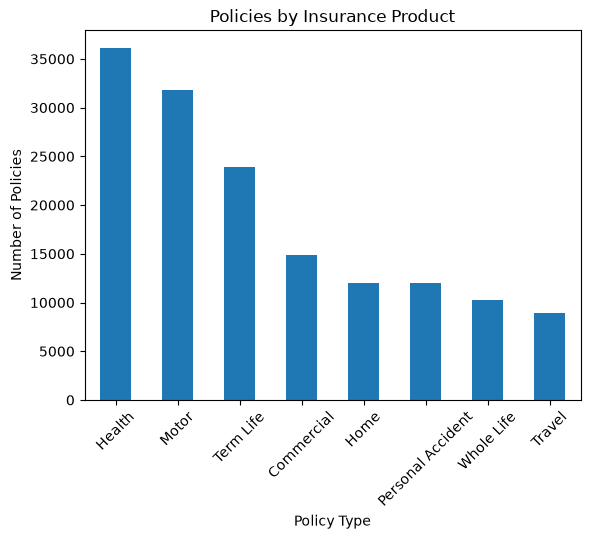

In [20]:
(
    policy_type_summary
    .set_index("POLICY_TYPE")
    ["POLICY_COUNT"]
    .plot(
        kind="bar"
    )
)

plt.title(
    "Policies by Insurance Product"
)

plt.xlabel(
    "Policy Type"
)

plt.ylabel(
    "Number of Policies"
)

plt.xticks(rotation=45)

plt.show()

In [21]:
policy_status_summary = (
    policies_df[
        "POLICY_STATUS"
    ]
    .value_counts()
    .to_frame(
        name="POLICY_COUNT"
    )
)

policy_status_summary[
    "PERCENTAGE"
] = (
    policy_status_summary["POLICY_COUNT"]
    /
    len(policies_df)
    * 100
)

policy_status_summary

,POLICY_COUNT,PERCENTAGE
POLICY_STATUS,,
Active,104959,69.972667
Expired,21019,14.012667
Lapsed,14914,9.942667
Cancelled,9108,6.072000


Insurance meaning
Active

Policy is marked as in-force.

Expired

Coverage period completed.

Lapsed

Policy stopped because conditions such as premium continuation/renewal weren't maintained.

Cancelled

Policy was explicitly terminated.

Sales Channel Analysis

Insurance can be sold through:

Agent
Broker
Online
Direct
Bank/Bancassurance
Corporate Partner

In [22]:
channel_summary = (
    policies_df
    .groupby("SALES_CHANNEL")
    .agg(
        POLICY_COUNT=("POLICY_ID", "count"),
        TOTAL_ANNUAL_PREMIUM=(
            "ANNUAL_PREMIUM",
            "sum"
        ),
        AVG_ANNUAL_PREMIUM=(
            "ANNUAL_PREMIUM",
            "mean"
        )
    )
    .reset_index()
)

In [23]:
channel_summary.sort_values(
    "POLICY_COUNT",
    ascending=False
)

,SALES_CHANNEL,POLICY_COUNT,TOTAL_ANNUAL_PREMIUM,AVG_ANNUAL_PREMIUM
1,Bancassurance,25305,485706385,19194.087532
3,Corporate Partner,25171,483398257,19204.571014
0,Agent,25043,482063227,19249.420077
4,Direct,24957,476127595,19077.917819
2,Broker,24791,476772962,19231.695454
5,Online,24733,475202745,19213.307929


Because customer contains:

STATE
CITY

In [24]:
state_summary = (
    customer_policy_df
    .groupby("STATE")
    .agg(
        POLICY_COUNT=("POLICY_ID", "count"),
        TOTAL_ANNUAL_PREMIUM=(
            "ANNUAL_PREMIUM",
            "sum"
        ),
        AVG_ANNUAL_PREMIUM=(
            "ANNUAL_PREMIUM",
            "mean"
        ),
        UNIQUE_CUSTOMERS=(
            "CUSTOMER_ID",
            "nunique"
        )
    )
    .reset_index()
)

In [25]:
state_summary.sort_values(
    "TOTAL_ANNUAL_PREMIUM",
    ascending=False
)

,STATE,POLICY_COUNT,TOTAL_ANNUAL_PREMIUM,AVG_ANNUAL_PREMIUM,UNIQUE_CUSTOMERS
8,Telangana,13833,266604656,19273.090147,7186
7,Tamil Nadu,13753,264130823,19205.324147,7125
5,Odisha,13783,263045808,19084.800697,7163
3,Kerala,13730,262399063,19111.366570,7049
10,West Bengal,13609,262334106,19276.515982,7112
6,Rajasthan,13602,262067408,19266.828996,7122
1,Gujarat,13749,262059513,19060.259873,7203
9,Uttar Pradesh,13515,260258626,19257.020052,6994
2,Karnataka,13507,259937664,19244.663064,7022
4,Maharashtra,13450,259638945,19304.010781,6959


Customer Risk Profile

Now analyze:

Low
Medium
High

In [26]:
risk_summary = (
    customers_df[
        "CUSTOMER_RISK_SEGMENT"
    ]
    .value_counts()
    .to_frame(
        name="CUSTOMERS"
    )
)

risk_summary[
    "PERCENTAGE"
] = (
    risk_summary["CUSTOMERS"]
    /
    len(customers_df)
    * 100
)

risk_summary

,CUSTOMERS,PERCENTAGE
CUSTOMER_RISK_SEGMENT,,
Low,54974,54.974
Medium,34012,34.012
High,11014,11.014


Do High-Risk Customers Pay Higher Premiums?

In [27]:
risk_premium_summary = (
    customer_policy_df
    .groupby(
        "CUSTOMER_RISK_SEGMENT"
    )
    .agg(
        POLICY_COUNT=("POLICY_ID", "count"),
        AVG_ANNUAL_PREMIUM=(
            "ANNUAL_PREMIUM",
            "mean"
        ),
        TOTAL_ANNUAL_PREMIUM=(
            "ANNUAL_PREMIUM",
            "sum"
        )
    )
    .reset_index()
)

risk_premium_summary

,CUSTOMER_RISK_SEGMENT,POLICY_COUNT,AVG_ANNUAL_PREMIUM,TOTAL_ANNUAL_PREMIUM
0,High,16630,19208.835719,319442938
1,Low,82479,19158.459353,1580170569
2,Medium,50891,19250.116209,979657664


Build our first business summary table

In [28]:
business_summary = pd.DataFrame({

    "METRIC": [
        "Total Customers",
        "Policyholders",
        "Customers without Policy",
        "Total Policies",
        "Avg Policies per Policyholder",
        "Total Annual Premium",
        "Avg Annual Premium"
    ],

    "VALUE": [
        total_customers,
        policy_customers,
        customers_without_policy,
        total_policies,
        round(
            avg_policies_per_policyholder,
            2
        ),
        total_annual_premium,
        round(
            avg_annual_premium,
            2
        )
    ]
})

business_summary

,METRIC,VALUE
0,Total Customers,1.000000e+05
1,Policyholders,7.789100e+04
2,Customers without Policy,2.210900e+04
3,Total Policies,1.500000e+05
4,Avg Policies per Policyholder,1.930000e+00
5,Total Annual Premium,2.879271e+09
6,Avg Annual Premium,1.919514e+04


What have we learned from Stage 3?

100K Customer Master
        ↓
77.9K customers hold policies
        ↓
150K total policies
        ↓
~1.93 policies/policyholder
        ↓
Health + Motor dominate policy volume
        ↓
Commercial generates highest annual premium contribution
        ↓
~70% policies are marked Active
        ↓
Channels/geographies are relatively balanced
        ↓
55% customers are Low Risk
        ↓
Customer risk segment alone does not strongly explain premium